# Video Game Sales Analysis & Market Strategy

### File and data

#### Import the libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats as st

#### Upload the file

In [ ]:
df_games = pd.read_csv('Data/games.csv')

#### Exploratory data analysis
#### Data analysis (data type, missing values, etc.)

In [3]:
df_games.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


### Data cleaning
#### Change column names to lowercase

In [4]:
df_games.columns = df_games.columns.str.lower()

print(df_games.info())

df_games


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


#### Convert data 
#### Convert the column data 'year_of_release' to integer

In [5]:
df_games['year_of_release'] = pd.to_numeric(df_games['year_of_release'], errors='coerce')
print("Column 'year_of_release' type:", df_games['year_of_release'].dtypes)

#Convert the column data 'critic_score' to integer
df_games['critic_score'] = pd.to_numeric(df_games['critic_score'], errors='coerce')
print("Column 'critic_score' type:", df_games['critic_score'].dtypes)
#Review for NaN values in 'user_score'  
print("Empty values in 'user_score':", df_games['user_score'].isna().sum())

#Convert the column data 'critic_score' to float
df_games['user_score'] = pd.to_numeric(df_games['user_score'], errors='coerce')
print("Column 'user_score' type:", df_games['user_score'].dtypes)

print()

df_games.info()


Column 'year_of_release' type: float64
Column 'critic_score' type: float64
Empty values in 'user_score': 6701
Column 'user_score' type: float64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: float64(7), object(4)
memory usage: 1.4+ MB


#### Describe the columns in which the data types have been changed and explain why.
It was decided to change the data type for the 'year_of_release' and 'critic_score' columns because their data type did not match the data present in those columns (integer numbers).

### Empty data

In [6]:
df_games.info()
#Fill missing values in 'name' with 'Unknown'
print("Empty values in 'name' at the start:", df_games['name'].isna().sum())
df_games['name'] = df_games['name'].fillna('Unknown')
print("Empty values in 'name' at the end:", df_games['name'].isna().sum())
#Fill missing values in 'genre' with 'Unknown'
print("Empty values in 'genre' at the start:", df_games['genre'].isna().sum())
df_games['genre'] = df_games['genre'].fillna('Unknown')
print("Empty values in 'genre' at the end:", df_games['genre'].isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: float64(7), object(4)
memory usage: 1.4+ MB
Empty values in 'name' at the start: 2
Empty values in 'name' at the end: 0
Empty values in 'genre' at the start: 2
Empty values in 'genre' at the end: 0


-Missgin data has been filled for 'name' and 'genre' columns with 'Unknown', now there are no empty values in these columns.

-Other columns with missing data will be left as they are, since filling them with mean/median/mode or deleting rows may affect the analysis.

-Probably, columns with missing data coulb be empty due to missing information about the videogame as reviews, rate or critics.

-Finally, the TBD data weere changed for NaN.

In [7]:
df_games['total_sales'] = df_games[['eu_sales', 'jp_sales', 'na_sales', 'other_sales']].sum(axis = 1)

df_games


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38
...,...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN,0.01
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN,0.01


### Data Analysis
#### Analyzes the number of video games released per year

Number of rows without year of release: 269
Number of rows without year of release: 269


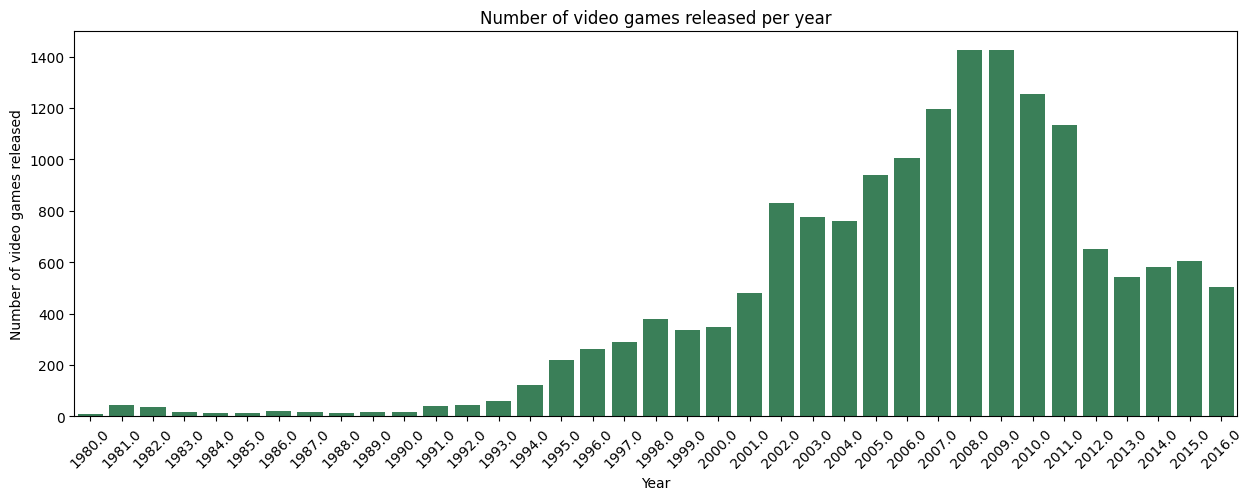

In [9]:
print('Number of rows without year of release:', df_games['year_of_release'].isna().sum())


games_without_yor = df_games[~df_games['year_of_release'].isna()]
games_per_year = games_without_yor.groupby('year_of_release').size().reset_index(name='count')


plt.figure(figsize=(15, 5))
sns.barplot(data = games_per_year, x = 'year_of_release', y ='count', color = 'seagreen')
plt.title('Number of video games released per year')
plt.xlabel('Year')
plt.ylabel('Number of video games released')
plt.xticks(rotation=45)
print('Number of rows without year of release:', df_games['year_of_release'].isna().sum())


games_without_yor = df_games[~df_games['year_of_release'].isna()]
plt.show()


#### Analyze the total sales of different video game platforms

Number of rows without sales data: 0


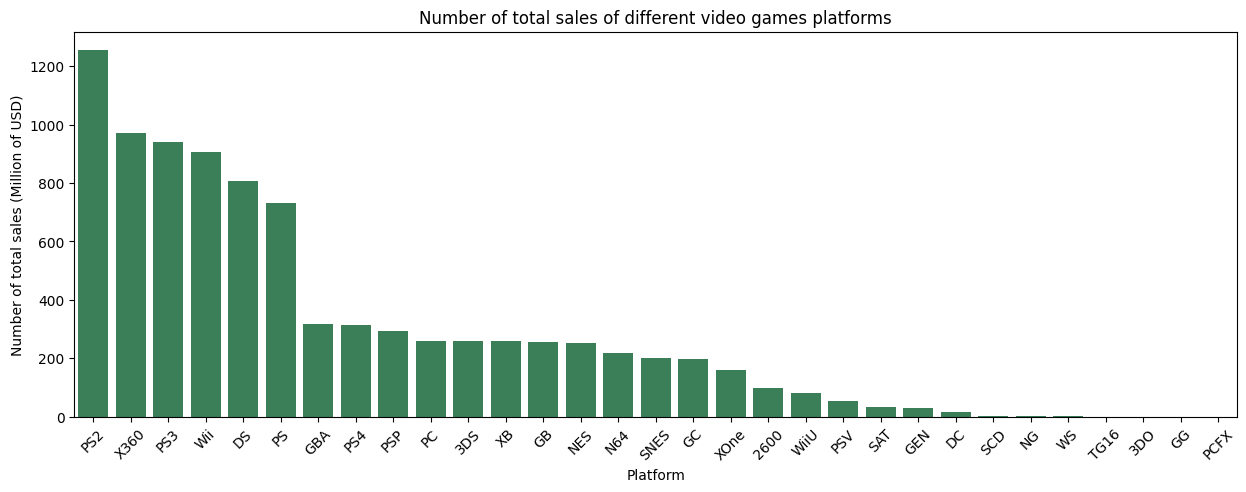

In [10]:
print('Number of rows without sales data:', df_games['total_sales'].isna().sum())


platform_sales = df_games.groupby('platform')['total_sales'].sum().reset_index(name='count').sort_values('count', ascending = False)

plt.figure(figsize=(15, 5))
sns.barplot(data = platform_sales, x = 'platform', y ='count', color = 'seagreen')
plt.title('Number of total sales of different video games platforms')
plt.xlabel('Platform')
plt.ylabel('Number of total sales (Million of USD)')
plt.xticks(rotation=45)
plt.show()
platform_sales = df_games.groupby('platform')['total_sales'].sum().reset_index(name='count').sort_values('count', ascending = False).head(5)



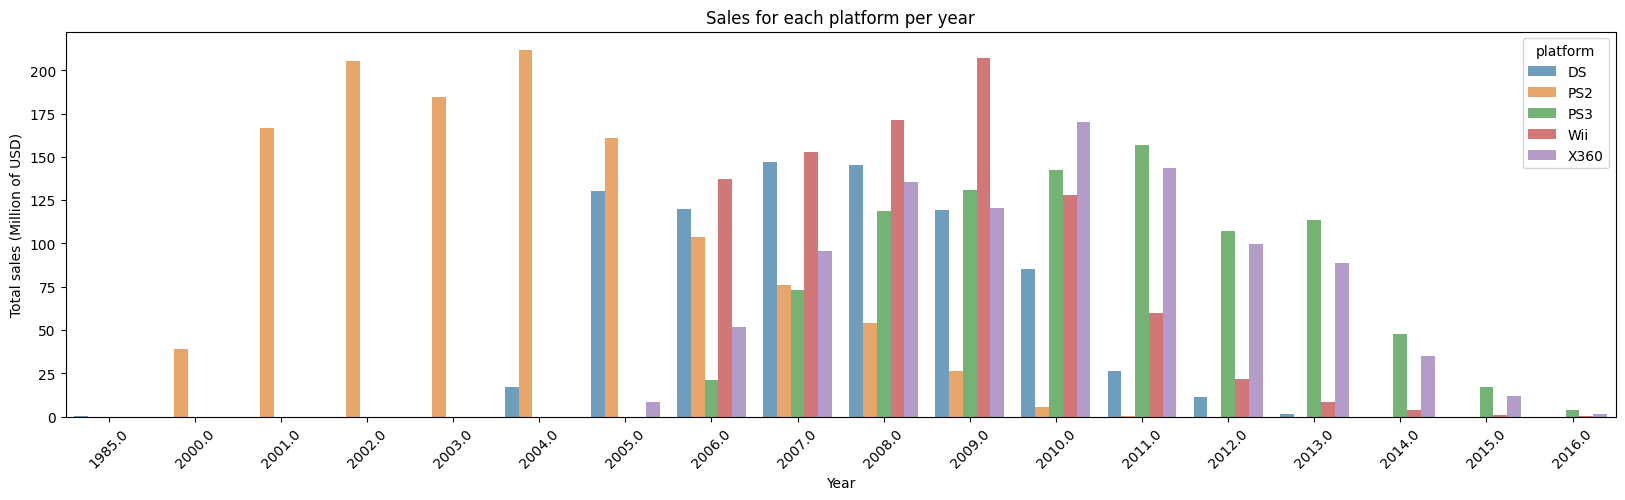

In [11]:
top_platforms = platform_sales['platform'].tolist()

df_top_platforms = df_games[df_games['platform'].isin(top_platforms)]

yearly_distribution = df_top_platforms.groupby(['platform', 'year_of_release'])['total_sales'].sum().reset_index()

plt.figure(figsize=(20, 5))
sns.barplot(data = yearly_distribution, x='year_of_release', y='total_sales', hue='platform', alpha=0.7)
plt.title('Sales for each platform per year')
plt.xlabel('Year')
plt.ylabel('Total sales (Million of USD)')
plt.xticks(rotation=45)
plt.show()


#### Look for platforms that used to be popular but are now losing sales. How long does it typically take for new platforms to appear and old ones to disappear?

In [12]:
yearly_distribution_df_games = df_games.groupby(['platform', 'year_of_release'])['total_sales'].sum().reset_index()

yearly_distribution_2011 = yearly_distribution_df_games[yearly_distribution_df_games['year_of_release'] == 2011]
platforms_2011 = yearly_distribution_2011['platform'].unique()
set_2011 = set(platforms_2011)

yearly_distribution_2016 = yearly_distribution_df_games[yearly_distribution_df_games['year_of_release'] == 2016]
platforms_2016 = yearly_distribution_2016['platform'].unique()
set_2016 = set(platforms_2016)

platforms_in_2011_not_2016 = set_2011 - set_2016
print('The platforms that existed in 2011 but not in 2016 are:', platforms_in_2011_not_2016)

platforms_in_2016_not_2011 = set_2016 - set_2011
print('The platforms that existed in 2016 but not in 2011 are:', platforms_in_2016_not_2011)

The platforms that existed in 2011 but not in 2016 are: {'DS', 'PSP', 'PS2'}
The platforms that existed in 2016 but not in 2011 are: {'XOne', 'PS4', 'WiiU'}


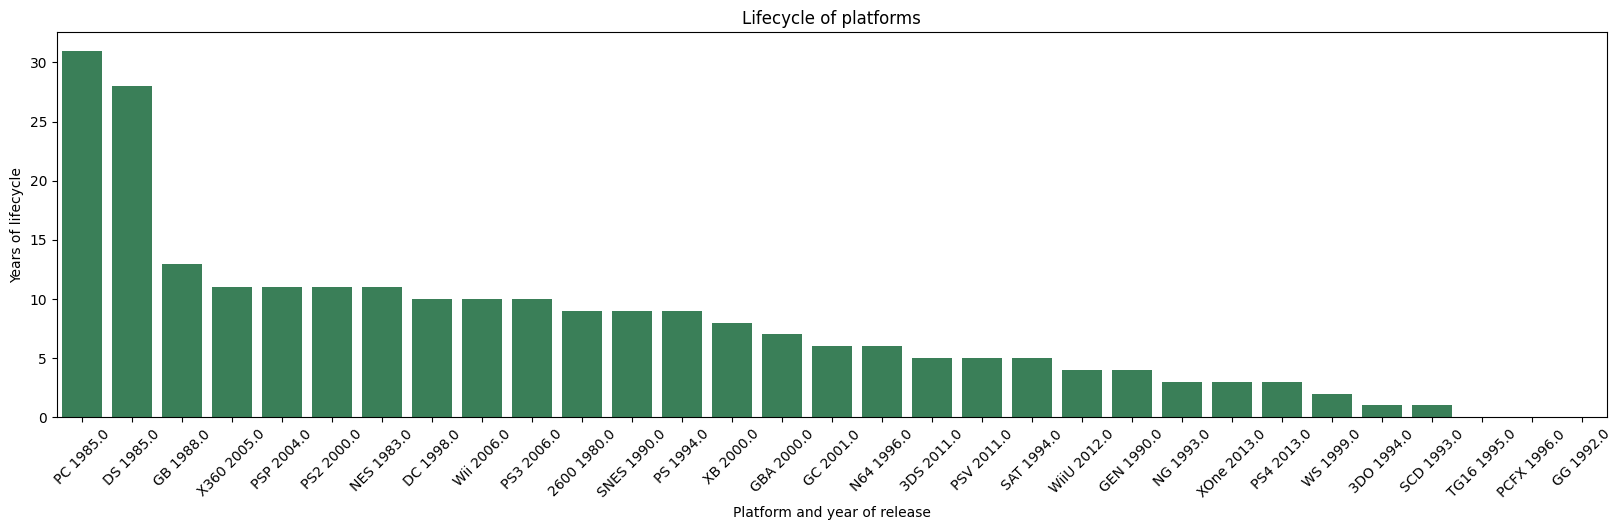

Old platforms take 7.89 years to disappear

New platforms take 7.23 years to disappear



In [13]:
# Encuentra el primer y último año de cada plataforma
platform_lifecycle = df_games.groupby('platform')['year_of_release'].agg(['min', 'max']).reset_index()
platform_lifecycle.columns = ['platform', 'first_year', 'last_year']

# Calcula cuántos años duró cada plataforma
platform_lifecycle['lifespan'] = platform_lifecycle['last_year'] - platform_lifecycle['first_year']

# Crear la columna combinada para el gráfico
platform_lifecycle['first_year_sales'] = platform_lifecycle['platform'] + ' ' + platform_lifecycle['first_year'].astype(str)

# Ordenar el DataFrame por lifespan para el gráfico
platform_lifecycle_sorted = platform_lifecycle.sort_values('lifespan', ascending=False)

# Crear el gráfico
plt.figure(figsize = (20, 5))
sns.barplot(data = platform_lifecycle_sorted, x = 'first_year_sales', y = 'lifespan', color = 'seagreen')
plt.title('Lifecycle of platforms')
plt.xlabel('Platform and year of release')
plt.ylabel('Years of lifecycle')
plt.xticks(rotation = 45)
plt.show()

old_platforms = (platform_lifecycle[platform_lifecycle['first_year'] < 2000]['lifespan']).mean()
print(f'Old platforms take {old_platforms:.2f} years to disappear')
print()
new_platforms = (platform_lifecycle[platform_lifecycle['first_year'] >= 2000]['lifespan']).mean()
print(f'New platforms take {new_platforms:.2f} years to disappear')
print()

#### Which platforms are liders in sales?

According with the analysis data, the platforms liders in sales are PS2, X360, PS3, WII, DS, PS, GBA, PS4, PSP and PC

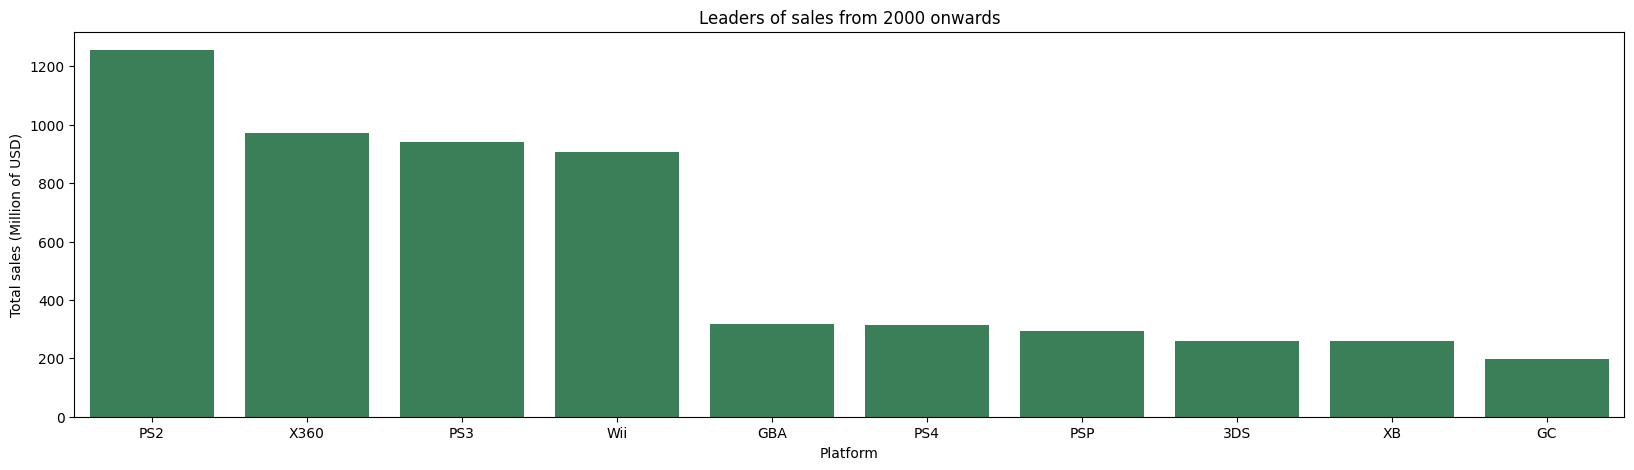

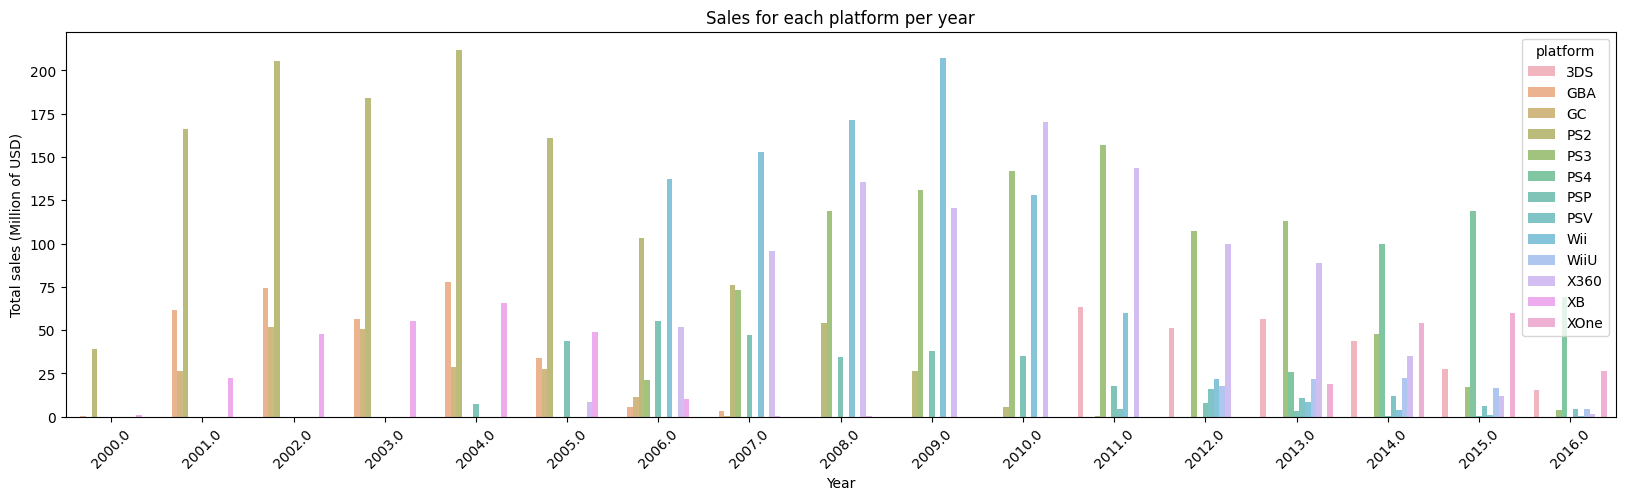

<Figure size 1500x600 with 0 Axes>

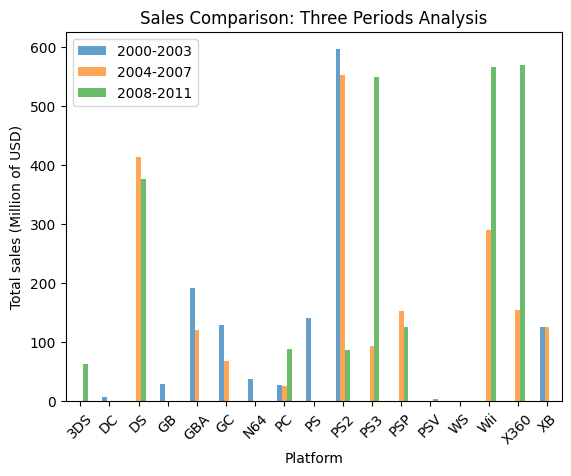

In [14]:
new_platforms_2000 = platform_lifecycle[platform_lifecycle['first_year'] >= 2000]
new_platforms_leaders = df_games[df_games['platform'].isin(new_platforms_2000['platform'])]
leaders_sales = new_platforms_leaders.groupby('platform')['total_sales'].sum().reset_index().sort_values('total_sales', ascending = False).head(10)
#Mainly leaders in sales from 2000
plt.figure(figsize = (20, 5))
sns.barplot(data = leaders_sales, x = 'platform', y = 'total_sales', color = 'seagreen')
plt.title('Leaders of sales from 2000 onwards')
plt.xlabel('Platform')
plt.ylabel('Total sales (Million of USD)')
plt.xticks(rotation = 0)
plt.show()

#Growth of the main sales-leading platforms
growth_yearly_distribution = new_platforms_leaders.groupby(['platform', 'year_of_release'])['total_sales'].sum().reset_index()
plt.figure(figsize=(20, 5))
sns.barplot(data = growth_yearly_distribution, x='year_of_release', y='total_sales', hue='platform', alpha=0.7)
plt.title('Sales for each platform per year')
plt.xlabel('Year')
plt.ylabel('Total sales (Million of USD)')
plt.xticks(rotation=45)
plt.show()


#Complementary analysis
# Dividir en períodos
periodo_1 = df_games[(df_games['year_of_release'] >= 2000) & (df_games['year_of_release'] <= 2003)]
periodo_2 = df_games[(df_games['year_of_release'] >= 2004) & (df_games['year_of_release'] <= 2007)]
periodo_3 = df_games[(df_games['year_of_release'] >= 2008) & (df_games['year_of_release'] <= 2011)]

# Calcular ventas por período
early_sales = periodo_1.groupby('platform')['total_sales'].sum()
middle_sales = periodo_2.groupby('platform')['total_sales'].sum()
recent_sales = periodo_3.groupby('platform')['total_sales'].sum()

# Ahora sí puedes crear el comparison_df
comparison_df = pd.DataFrame({
    'early_period': early_sales,
    'middle_period' : middle_sales,
    'recent_period': recent_sales
    
}).fillna(0)

# Gráfico de barras comparativo con los 3 períodos
plt.figure(figsize=(15, 6))
comparison_df[['early_period', 'middle_period', 'recent_period']].plot(kind='bar', alpha=0.7)
plt.title('Sales Comparison: Three Periods Analysis')
plt.xlabel('Platform')
plt.ylabel('Total sales (Million of USD)')
plt.xticks(rotation=45)
plt.legend(['2000-2003', '2004-2007', '2008-2011'])
plt.show()

### Which platforms are leading in sales? Which ones are growing and which ones are declining? Choose several potentially profitable platforms.

According with the analysis, the mainly leaders in sales, from 2000 and onwards, are DS, PS2 and  PSP. On the other hand, the platforms PS3, WII and X360 has a increment in the sales volume from 2000 and onwards.
PS3, WII and X360 are some potentially profitable platforms.

### Total sales boxplot

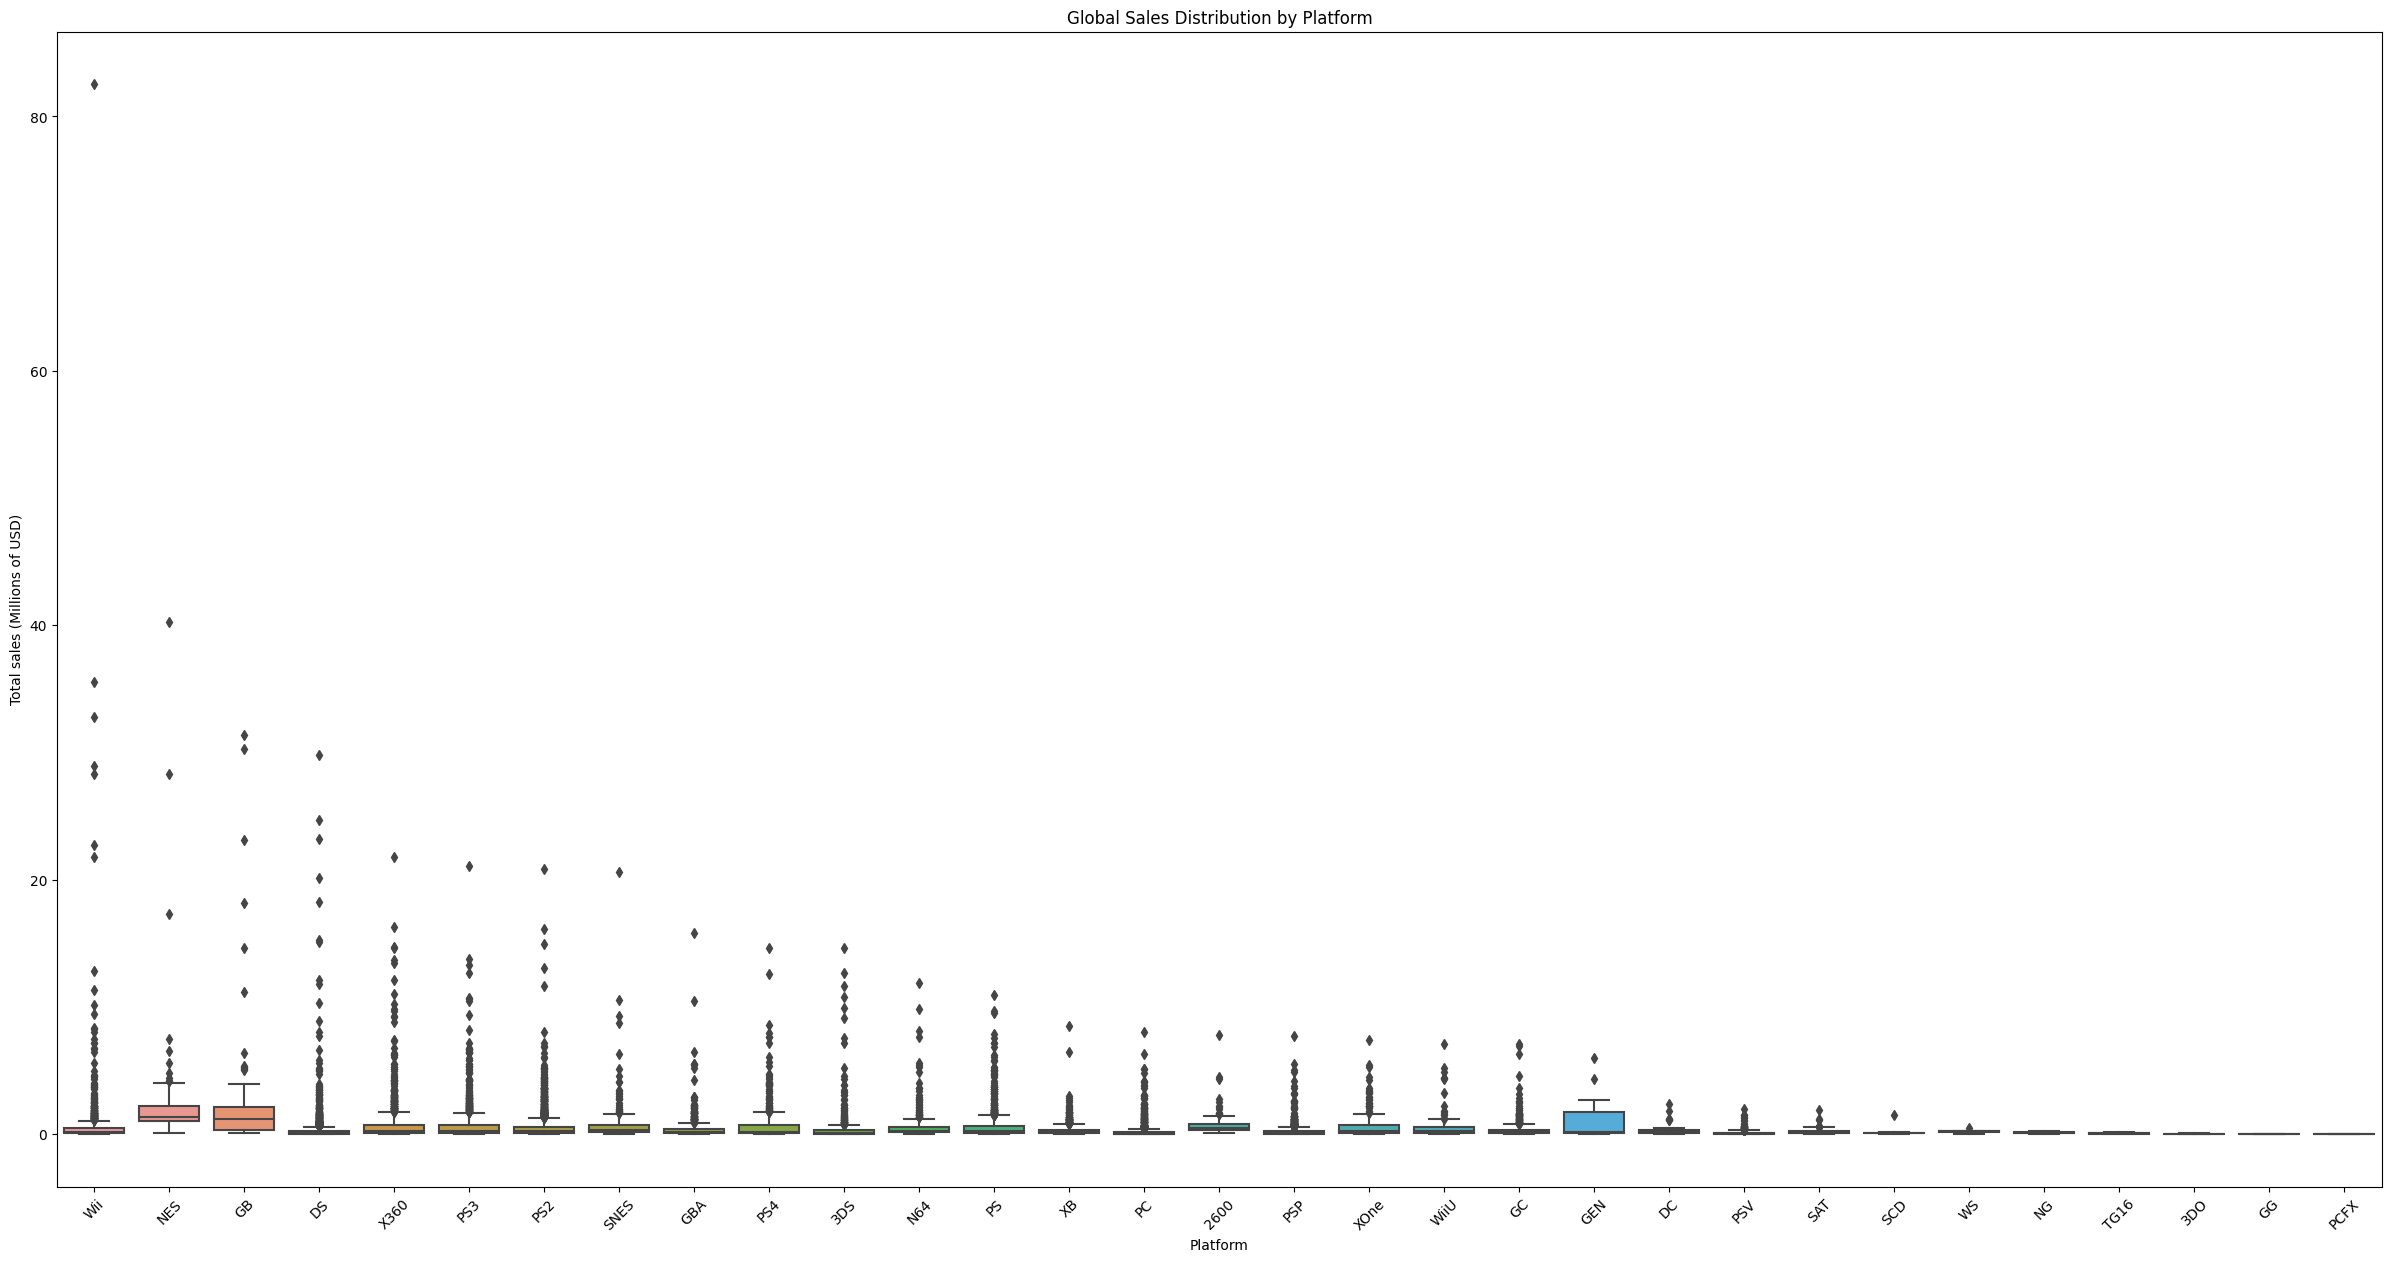

Top 10 platforms by average sales:
          count  mean  median   std   min    max
platform                                        
GB           98  2.61    1.16  5.37  0.06  31.38
NES          98  2.56    1.38  5.11  0.06  40.24
GEN          29  1.06    0.15  1.47  0.03   6.02
SNES        239  0.84    0.32  1.87  0.01  20.62
PS4         392  0.80    0.20  1.61  0.01  14.63
X360       1262  0.77    0.28  1.62  0.01  21.82
2600        133  0.73    0.46  0.92  0.07   7.81
PS3        1331  0.71    0.27  1.39  0.00  21.05
N64         319  0.69    0.27  1.32  0.01  11.90
Wii        1320  0.69    0.19  3.13  0.01  82.54


In [ ]:
plt.figure(figsize=(30, 15))
sns.boxplot(data=df_games, x='platform', y='total_sales')
plt.title('Global Sales Distribution by Platform')
plt.xlabel('Platform')
plt.ylabel('Total sales (Millions of USD)')
plt.xticks(rotation=45)
plt.show()

platform_stats = df_games.groupby('platform')['total_sales'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)

platform_stats_sorted = platform_stats.sort_values('mean', ascending=False)
print("Top 10 platforms by average sales:")
print(platform_stats_sorted.head(10))

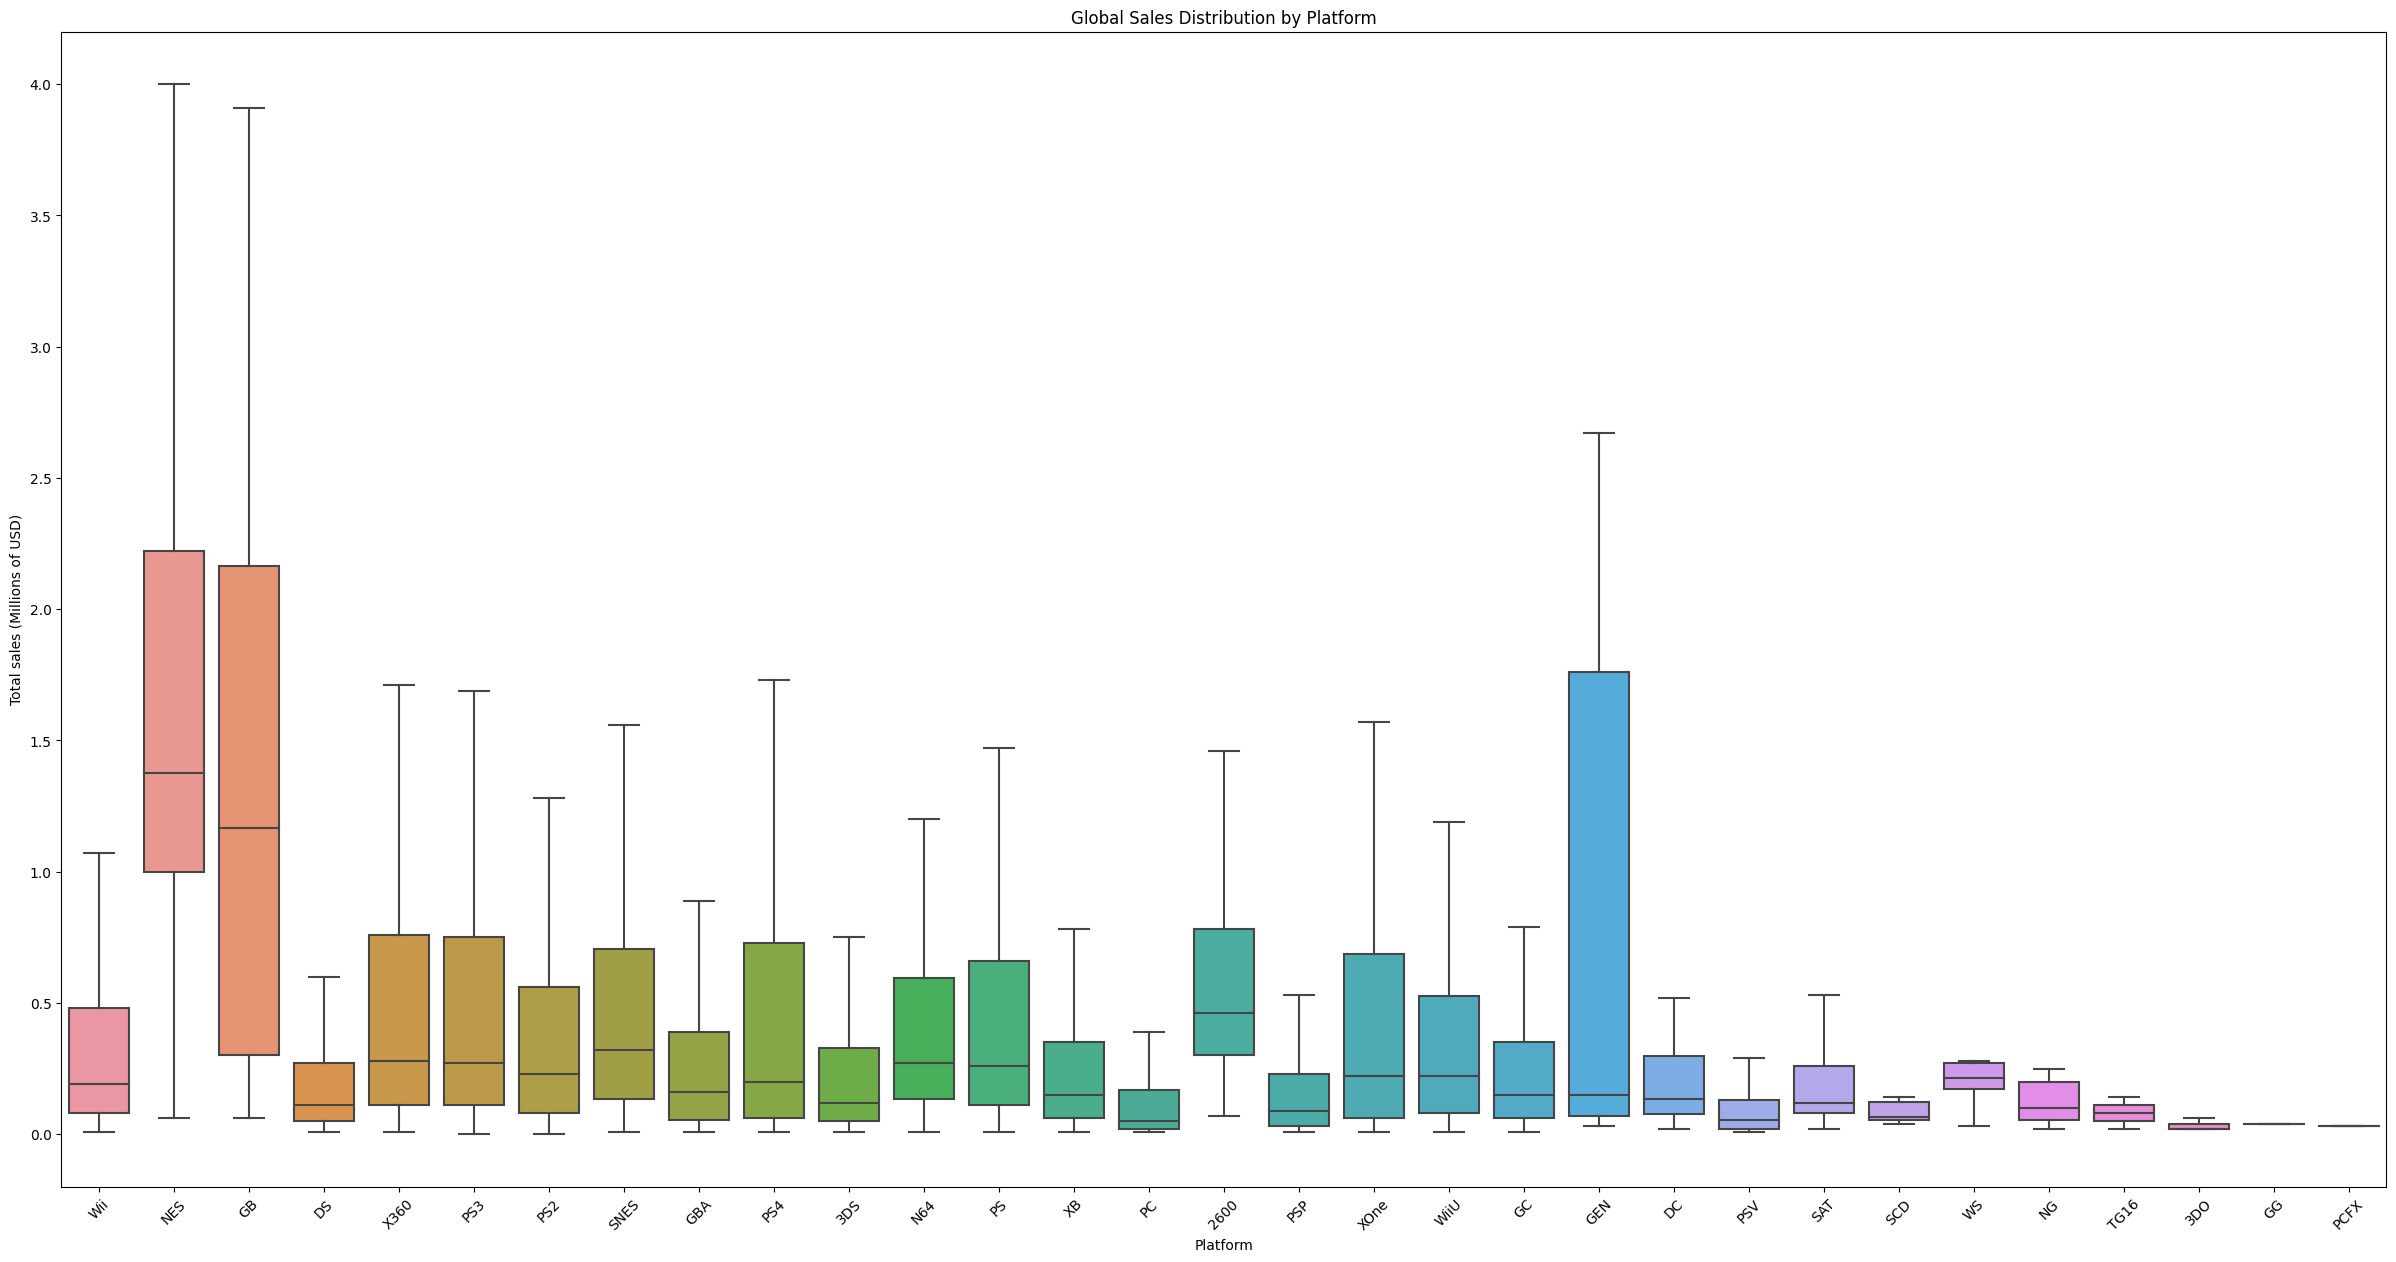

In [16]:
plt.figure(figsize=(30, 15))
sns.boxplot(data=df_games, x='platform', y='total_sales', showfliers = False)
plt.title('Global Sales Distribution by Platform')
plt.xlabel('Platform')
plt.ylabel('Total sales (Millions of USD)')
plt.xticks(rotation=45)
plt.show()


### Are the differences in sales significant? What about average sales across platforms?

There are clear differences in sales between platforms, as well as in their average sales. It’s recommended to carry out a statistical analysis to compare the sales of each platform and identify whether these differences are significant and which platforms stand out. 
Based on the boxplot, the presence of several outliers is observed in most sales for most platforms.

### Reviews and sales for X360

X360 games with full data: 881


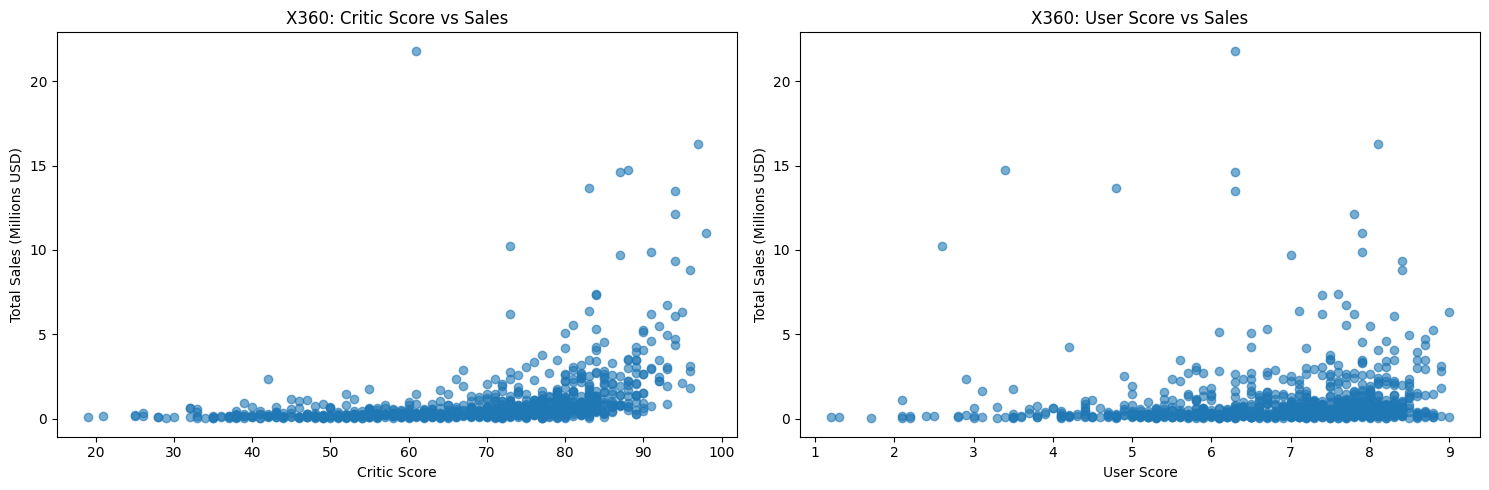

Correlación Critic Score - Ventas: 0.390
Correlación User Score - Ventas: 0.110


In [17]:
x360_data = df_games[df_games['platform']== 'X360']

# Filtrar solo juegos con ambas puntuaciones y ventas disponibles
x360_complete = x360_data.dropna(subset=['critic_score', 'user_score', 'total_sales'])
print(f"X360 games with full data: {len(x360_complete)}")

# Gráfico de dispersión: Critic Score vs Ventas
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.scatter(x360_complete['critic_score'], x360_complete['total_sales'], alpha=0.6)
plt.xlabel('Critic Score')
plt.ylabel('Total Sales (Millions USD)')
plt.title('X360: Critic Score vs Sales')

plt.subplot(1, 2, 2)
plt.scatter(x360_complete['user_score'], x360_complete['total_sales'], alpha=0.6)
plt.xlabel('User Score')
plt.ylabel('Total Sales (Millions USD)')
plt.title('X360: User Score vs Sales')

plt.tight_layout()
plt.show()


critic_correlation = x360_complete['critic_score'].corr(x360_complete['total_sales'])
user_correlation = x360_complete['user_score'].corr(x360_complete['total_sales'])

print(f"Correlación Critic Score - Ventas: {critic_correlation:.3f}")
print(f"Correlación User Score - Ventas: {user_correlation:.3f}")

Based on the observed results, it is concluded that there is very little correlation between reviews and sales for the X360 platform, so it would be incorrect to think about projecting sales based on reviews.

### Sales comparison. Games on other platforms.

In [18]:
#Find the games for xbox on multiple platforms
games_multiplatform = df_games.groupby('name')['platform'].nunique()
games_on_multiple_platforms = games_multiplatform[games_multiplatform > 1]

#x360_data = df_games[df_games['platform']== 'X360']
x360_games = set(x360_data['name'].unique())

#set() converts a list or array into a set, sets do not allow duplicate elements, it is useful for searching for elements.

multiplatform_games_X360 = []

for game in games_on_multiple_platforms.index:
    if game in x360_games:
        multiplatform_games_X360.append(game)
print('Numero of video games on X360 and others platforms:', len(multiplatform_games_X360))

#Sales comparation
sample_games = multiplatform_games_X360[:10]
comparison_data = []

for video_game in sample_games:
    game_data = df_games[df_games['name'] == video_game][['name', 'platform', 'total_sales']]
    comparison_data.append(game_data)

comparison_df = pd.concat(comparison_data, ignore_index=True)
print(comparison_df.head(20))

Numero of video games on X360 and others platforms: 1014
                                                 name platform  total_sales
0                              007: Quantum of Solace     X360         1.48
1                              007: Quantum of Solace      PS3         1.15
2                              007: Quantum of Solace      Wii         0.65
3                              007: Quantum of Solace      PS2         0.43
4                              007: Quantum of Solace       DS         0.13
5                              007: Quantum of Solace       PC         0.02
6                                   11eyes: CrossOver     X360         0.02
7                                   11eyes: CrossOver      PSP         0.02
8   2 in 1 Combo Pack: Sonic Heroes / Super Monkey...       XB         0.53
9   2 in 1 Combo Pack: Sonic Heroes / Super Monkey...     X360         0.11
10                   2010 FIFA World Cup South Africa      PS3         1.23
11                   2010 FIFA 

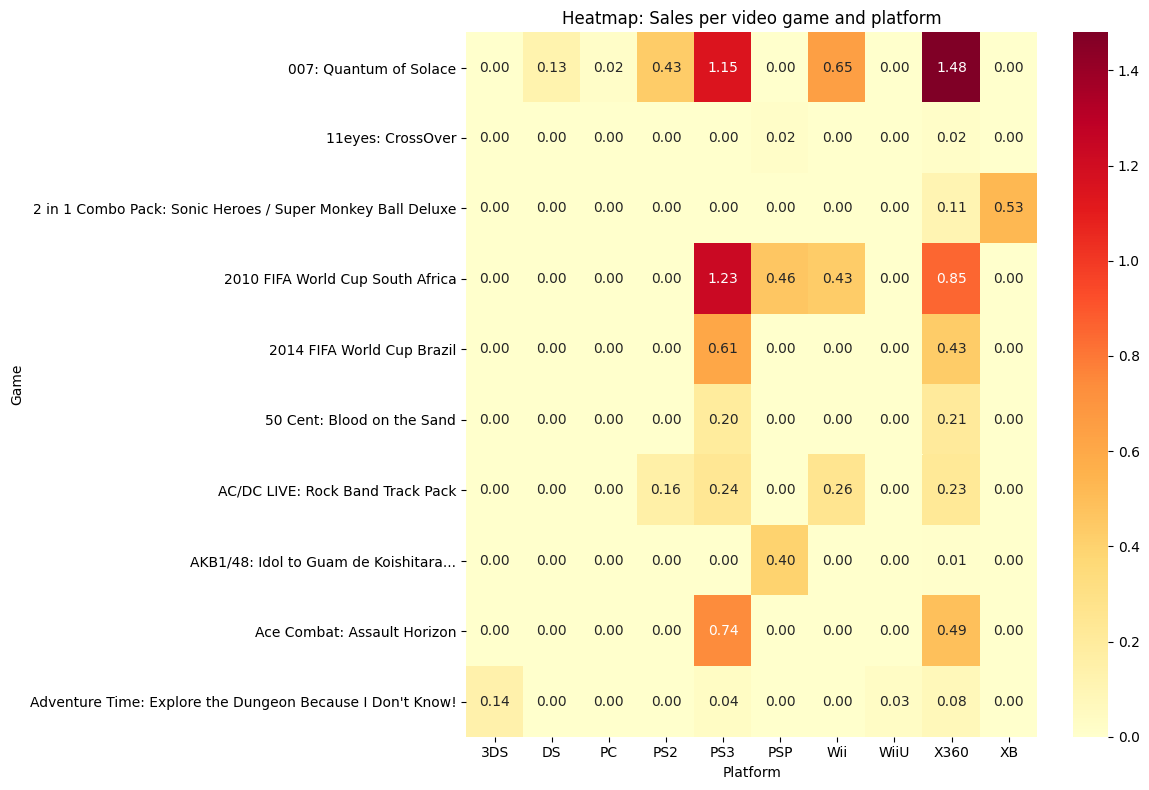

In [19]:
#Pivot table
pivot_data = comparison_df.pivot(index='name', columns='platform', values='total_sales')
pivot_data = pivot_data.fillna(0)

#Heatmap 
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_data, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Heatmap: Sales per video game and platform')
plt.xlabel('Platform')
plt.ylabel('Game')
plt.tight_layout()
plt.show()

According to the analysis, 007: Quantum of Solace is the best-selling video game on the X360 platform, while most other titles achieved higher sales on platforms other than X360. 
Based on the heatmap, it can be observed that sales are distributed according to the platform, that is, some games sell better on certain platforms than on others.


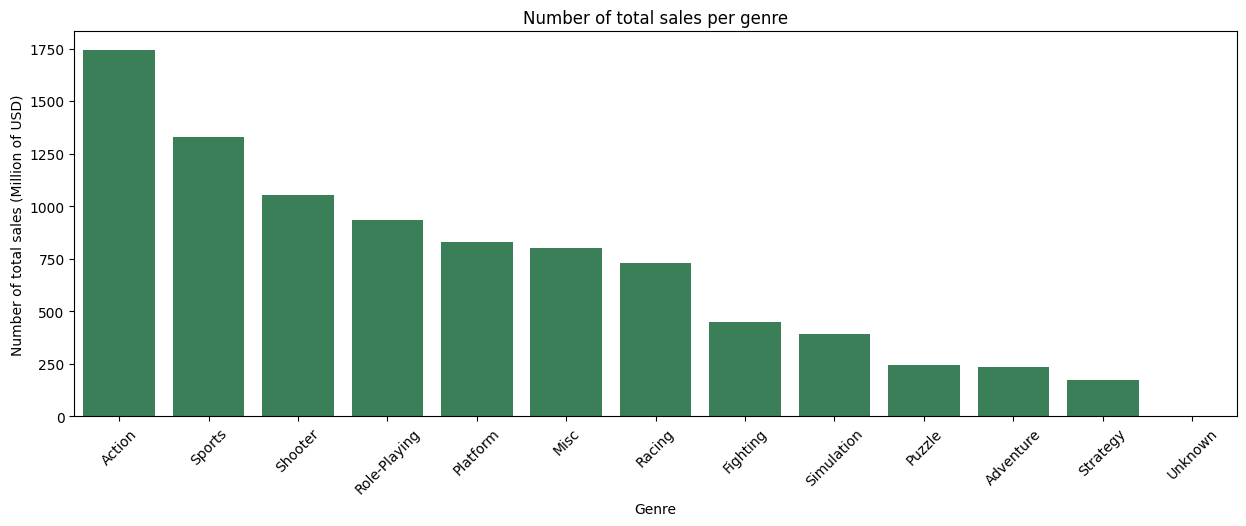

'007: Quantum of Solace' video game belongs to genre: Action


In [20]:
platform_sales = df_games.groupby('genre')['total_sales'].sum().reset_index(name='count').sort_values('count', ascending = False)

plt.figure(figsize=(15, 5))
sns.barplot(data = platform_sales, x = 'genre', y ='count', color = 'seagreen')
plt.title('Number of total sales per genre')
plt.xlabel('Genre')
plt.ylabel('Number of total sales (Million of USD)')
plt.xticks(rotation=45)
plt.show()

best_selling_game = df_games[df_games['name'] == '007: Quantum of Solace']['genre'].iloc[0]
print("'007: Quantum of Solace' video game belongs to genre:", best_selling_game)

According to the results, the best-selling video games are mainly from the action, sports, and shooter genres, which appear to have the highest sales.
"007: Quantum of Solace" is classified as an action game.

<Figure size 1500x800 with 0 Axes>

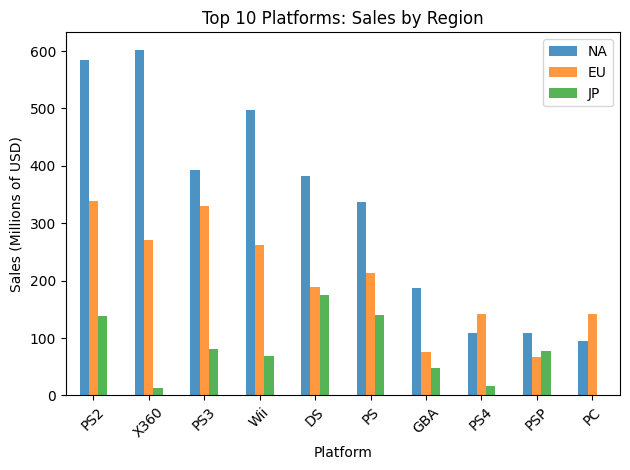

In [21]:
regions_comparison = pd.DataFrame({
    'NA': df_games.groupby('platform')['na_sales'].sum(),
    'EU': df_games.groupby('platform')['eu_sales'].sum(), 
    'JP': df_games.groupby('platform')['jp_sales'].sum()
}).fillna(0)

top_platforms = df_games.groupby('platform')['total_sales'].sum().nlargest(10).index
#.nlargest(10) toma los 10 valores más grandes de una serie y los devuelve ordenados de mayor a menor
regions_top = regions_comparison.loc[top_platforms]
#.loc[] selecciona filas o columnas por sus etiquetas (nombre o índices)

plt.figure(figsize=(15, 8))
regions_top.plot(kind='bar', alpha=0.8)
plt.title('Top 10 Platforms: Sales by Region')
plt.xlabel('Platform')
plt.ylabel('Sales (Millions of USD)')
plt.legend(['NA', 'EU', 'JP'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1500x800 with 0 Axes>

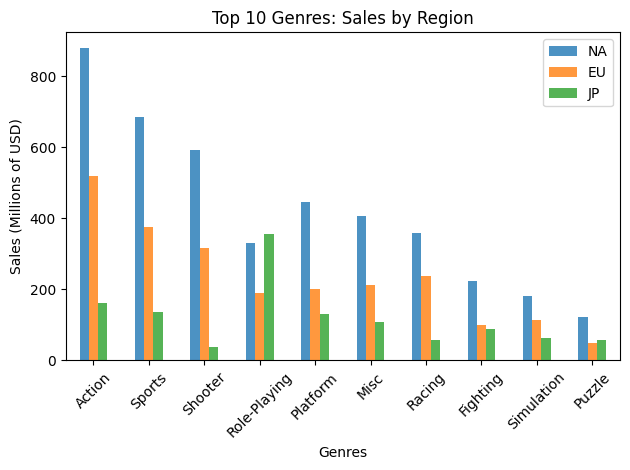

In [22]:
genres_comparison = pd.DataFrame({
    'NA': df_games.groupby('genre')['na_sales'].sum(),
    'EU': df_games.groupby('genre')['eu_sales'].sum(),
    'JP': df_games.groupby('genre')['jp_sales'].sum()
}).fillna(0)

genres = df_games.groupby('genre')['total_sales'].sum().nlargest(10).index
genres_top = genres_comparison.loc[genres]

plt.figure(figsize=(15, 8))
genres_top.plot(kind='bar', alpha=0.8)
plt.title('Top 10 Genres: Sales by Region')
plt.xlabel('Genres')
plt.ylabel('Sales (Millions of USD)')
plt.legend(['NA', 'EU', 'JP'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1500x800 with 0 Axes>

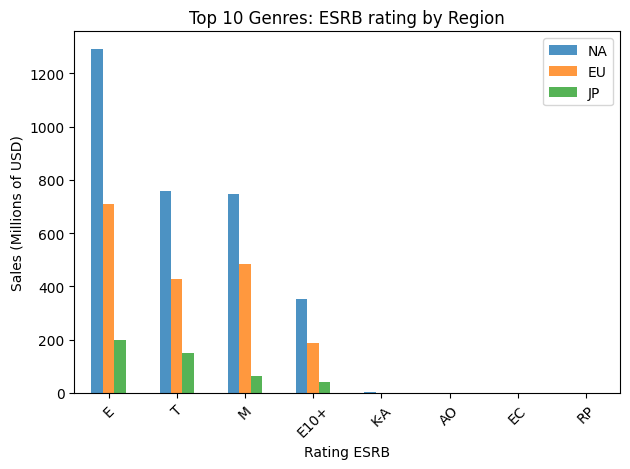

In [23]:
genres_comparison = pd.DataFrame({
    'NA': df_games.groupby('rating')['na_sales'].sum(),
    'EU': df_games.groupby('rating')['eu_sales'].sum(),
    'JP': df_games.groupby('rating')['jp_sales'].sum()
}).fillna(0)

rating = df_games.groupby('rating')['total_sales'].sum().nlargest(10).index
rating_top = genres_comparison.loc[rating]

plt.figure(figsize=(15, 8))
rating_top.plot(kind='bar', alpha=0.8)
plt.title('Top 10 Genres: ESRB rating by Region')
plt.xlabel('Rating ESRB')
plt.ylabel('Sales (Millions of USD)')
plt.legend(['NA', 'EU', 'JP'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

For NA consumers:
The main platforms for North American consumers are X360, PS2, Wii, PS3, and DS. The main genres are action, sports, shooter, platform, miscellaneous, and role-playing video games. The ESRB classification appears to determine total sales — the best-selling category is E, followed by T and M. The ESRB classification seems to influence regional sales in North America. This region has the highest sales compared to the EU and JP regions.

For EU consumers:
The main platforms for European consumers are PS2, PS3, X360, Wii, and PS. The main genres are action, sports, shooter, racing, and miscellaneous video games. According to the data analysis, the ESRB classification does not appear to determine total sales. This region ranks second in total sales, after North America.

For JP consumers:
The main platforms for Japanese consumers are DS, PS, PS2, PS3, and PSP. The main genres are role-playing, action, sports, platform, and miscellaneous. The ESRB classification appears to determine total sales — the best-selling category is E, followed by T and M. The ESRB classification seems to influence regional sales in Japan. This region ranks third in total sales.

### Hypothesis test

#### The average user ratings for the Xbox One and PC platforms are the same.

##### H0: The average user ratings for the Xbox One and PC platforms are the same.
##### H1: The average user ratings for the Xbox One and PC platforms are not the same.

In [24]:
rate_xbox_one = df_games[df_games['platform'] == 'XOne']['user_score'].dropna()
rate_pc = df_games[df_games['platform'] == 'PC']['user_score'].dropna()

alpha = 0.05
results = st.ttest_ind(rate_xbox_one, rate_pc, equal_var=False)

print(f"Xbox One - Sample size: {len(rate_xbox_one)}")
print(f"Xbox One - Sample mean: {rate_xbox_one.mean():.4f}")
print(f"Xbox One - Standard deviation: {rate_xbox_one.std():.4f}")
print()
print(f"PC - Sample size: {len(rate_pc)}")
print(f"PC - Sample mean: {rate_pc.mean():.4f}")
print(f"PC - Standard deviation: {rate_pc.std():.4f}")
print()
print(f'Valor p: {results.pvalue:.6f}')
print()

if results.pvalue < alpha:
    print('The null hypothesis has been rejected, the average user ratings for the Xbox One and PC platforms are not the same.')
else:
    print('The null hypothesis could not be rejected; there is insufficient evidence to conclude that the mean grades are different.')


Xbox One - Sample size: 182
Xbox One - Sample mean: 6.5214
Xbox One - Standard deviation: 1.3809

PC - Sample size: 770
PC - Sample mean: 7.0625
PC - Standard deviation: 1.5300

Valor p: 0.000005

The null hypothesis has been rejected, the average user ratings for the Xbox One and PC platforms are not the same.


### Average user ratings for the Action and Sports genres vary.

##### H0: Average user ratings for the Action and Sports genres are equal. 
##### H1: Average user ratings for the Action and Sports genres vary.

In [25]:
rate_action = df_games[df_games['genre'] == 'Action']['user_score'].dropna()
rate_sports = df_games[df_games['genre'] == 'Sports']['user_score'].dropna()

alpha = 0.05
results = st.ttest_ind(rate_action, rate_sports, equal_var=False)

print(f"Action - Sample size: {len(rate_action)}")
print(f"Action - Sample mean: {rate_action.mean():.4f}")
print(f"Action - Standard deviation: {rate_action.std():.4f}")
print()
print(f"Sports - Sample size: {len(rate_sports)}")
print(f"Sports - Sample mean: {rate_sports.mean():.4f}")
print(f"Sports - Standard deviation: {rate_sports.std():.4f}")
print()
print(f'Valor p: {results.pvalue:.6f}')
print()

if results.pvalue < alpha:
    print('The null hypothesis has been rejected, the average user ratings for the Action and Sports genres vary.')
else:
    print('The null hypothesis could not be rejected, there is insufficient evidence to conclude that the average user ratings for the Action and Sports genres are equal.')


Action - Sample size: 1830
Action - Sample mean: 7.0540
Action - Standard deviation: 1.4254

Sports - Sample size: 1103
Sports - Sample mean: 6.9612
Sports - Standard deviation: 1.6114

Valor p: 0.114838

The null hypothesis could not be rejected, there is insufficient evidence to conclude that the average user ratings for the Action and Sports genres are equal.


### Explain by yourself the meaning of alpha value

The p-value is the probability of obtaining the observed results assuming that the null hypothesis is true; in other words, it measures how likely the results are according to the null hypothesis.

### How did you formulate the null and alternative hypotheses?

For the first hypothesis test, I wrote that the null hypothesis would be that the average user ratings for Xbox One and PC are equal, since H₀ should be stated as an affirmative assumption. In this case, H₁ would represent the opposite, or the negation of H₀; that is, that the average user ratings would be different.

For the second hypothesis test, I considered that H₀ should have the same structure, following the statement that the average user ratings for the action and sports genres are equal, while H₁ would state that the average ratings are different.


### What criteria did you use to test the hypotheses and why?

For the first and second hypothesis test, I used an independent samples t-test with an alpha level of 0.05. To evaluate the test, I decided to use a two-tailed test because the problem did not specify whether the difference between the samples would be greater or smaller (as it would in a one-tailed test, for example). As well, I decided used the equal_var parameter as False due to variance in this value.

### Final conclusion

The data show that older platforms, that is, those released before the year 2000, take longer to disappear, while modern platforms (those launched after 2000) tend to have shorter life cycles.

The leading modern platforms in terms of sales were PS2, X360, PS3, Wii, GBA, PS4, PSP, 3DS, XB, and GC. In particular, the PS3, Wii, and X360 platforms were identified as potentially profitable, as they showed increases in sales during the analyzed period from 2000 to 2011.

The results revealed differences in sales among platforms, showing that not all of them perform similarly and that there are outliers in sales. This means that some platforms sell certain games in large quantities, while most remain within an average range, according to the boxplot analysis.

The sales analysis indicates a weak correlation between the number of sales and user reviews of a game, suggesting that sales should not be estimated based on this parameter.

Game sales vary across platforms; some popular and best-selling games, such as 007: Quantum of Solace, appear to lead sales on certain platforms, while on others they record few or no sales. In other words, sales differ from platform to platform — some games are well received on specific platforms, while others are not.

The main genres with the highest sales are action, sports, and shooter games. It is worth noting that these statistics vary by region; however, these three genres are the top sellers across all regions analyzed. Similarly, the leading platforms also vary by region, while some dominate sales in certain regions, they drop to second or third place in others. This could be due to differences in platform availability and user preferences.

It is concluded that user ratings for Xbox One and PC platforms are not statistically equal.

It is also concluded that user ratings for the action and sports genres are statistically similar, indicating that these are the preferred genres among platform users.

Finally, it is recommended to review the previously identified regional profiles to strategically plan marketing campaigns according to user preferences, as well as to consider the best-selling genres and platforms with the highest sales in each region.